In [55]:
#Importing modules needed for EDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
#Loading and preparing the dataset for EDA
df = pd.concat([pd.read_csv('churn-bigml-20.csv'), 
                pd.read_csv('churn-bigml-80.csv')], ignore_index=True)   # Combine datasets
df['Churn'] = df['Churn'].astype(int)
numeric_cols = df.select_dtypes(include='number').columns.tolist()  # Identify numeric columns

In [57]:
stats = df[numeric_cols].agg(['mean', 'median', 'var', 'std', 'min', 'max'])  # Calculate statistics
print(stats.T.round(3).to_string())

                           mean  median       var     std     min     max
Account length          101.065  101.00  1585.800  39.822    1.00  243.00
Area code               437.182  415.00  1795.326  42.371  408.00  510.00
Number vmail messages     8.099    0.00   187.371  13.688    0.00   51.00
Total day minutes       179.775  179.40  2966.696  54.467    0.00  350.80
Total day calls         100.436  101.00   402.768  20.069    0.00  165.00
Total day charge         30.562   30.50    85.737   9.259    0.00   59.64
Total eve minutes       200.980  201.40  2571.894  50.714    0.00  363.70
Total eve calls         100.114  100.00   396.911  19.923    0.00  170.00
Total eve charge         17.084   17.12    18.582   4.311    0.00   30.91
Total night minutes     200.872  201.20  2557.714  50.574   23.20  395.00
Total night calls       100.108  100.00   382.930  19.569   33.00  175.00
Total night charge        9.039    9.05     5.180   2.276    1.04   17.77
Total intl minutes       10.237   10.3

In [58]:
key_cols = ['Total day minutes', 'Total eve minutes',
            'Total night minutes', 'Total intl minutes',
            'Customer service calls', 'Account length'] # Key numeric columns for visualization

### Ploting Histograms

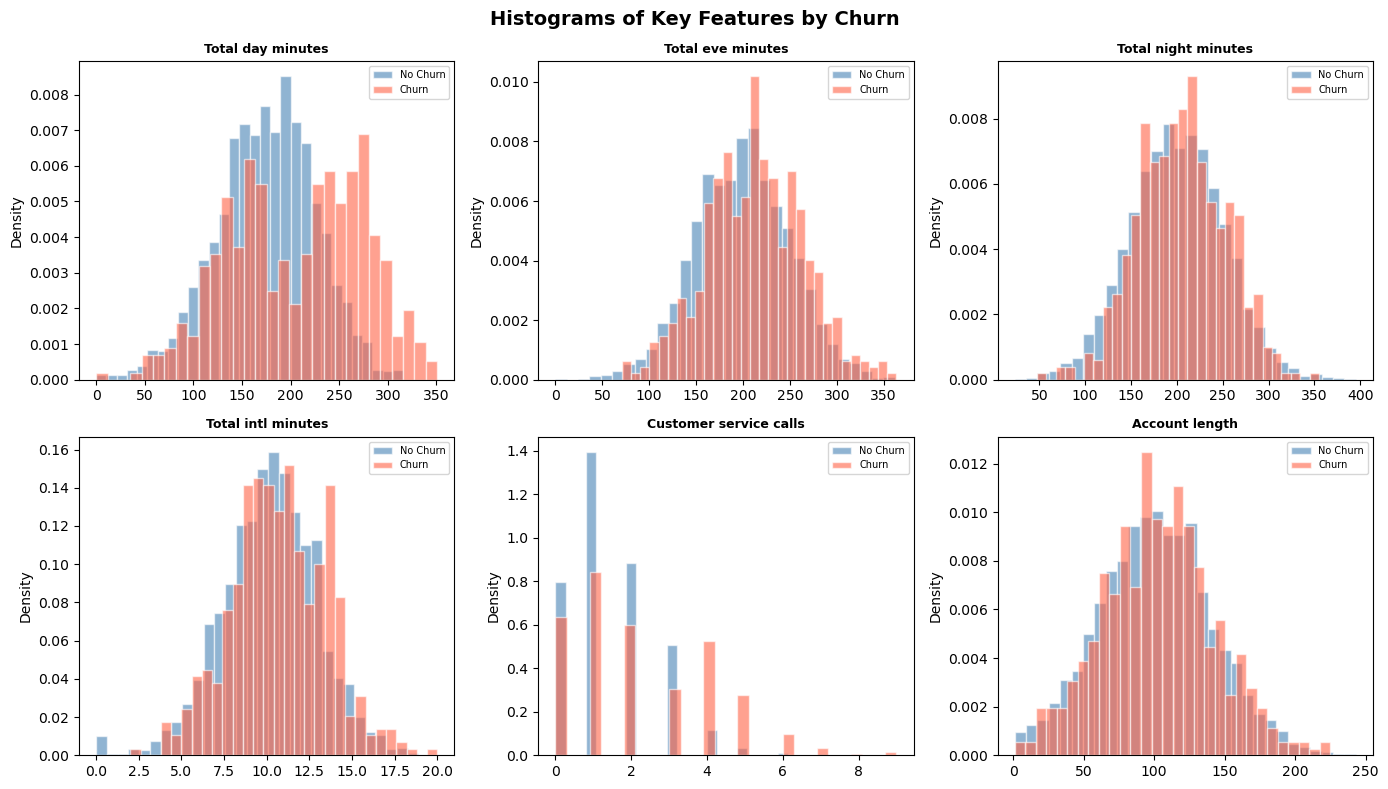

In [59]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Histograms of Key Features by Churn', fontsize=14, fontweight='bold')

for i, col in enumerate(key_cols): # Loop through key columns and plot histograms 
    ax = axes[i // 3, i % 3]       # Select the appropriate subplot
    for val, label, color in [(0, 'No Churn', 'steelblue'), (1, 'Churn', 'tomato')]: # Plot histograms for churn vs no churn
        ax.hist(df[df['Churn'] == val][col], bins=30, alpha=0.6,
                label=label, color=color, edgecolor='white', density=True) #
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)
plt.tight_layout()

### Ploting Scatter Plots

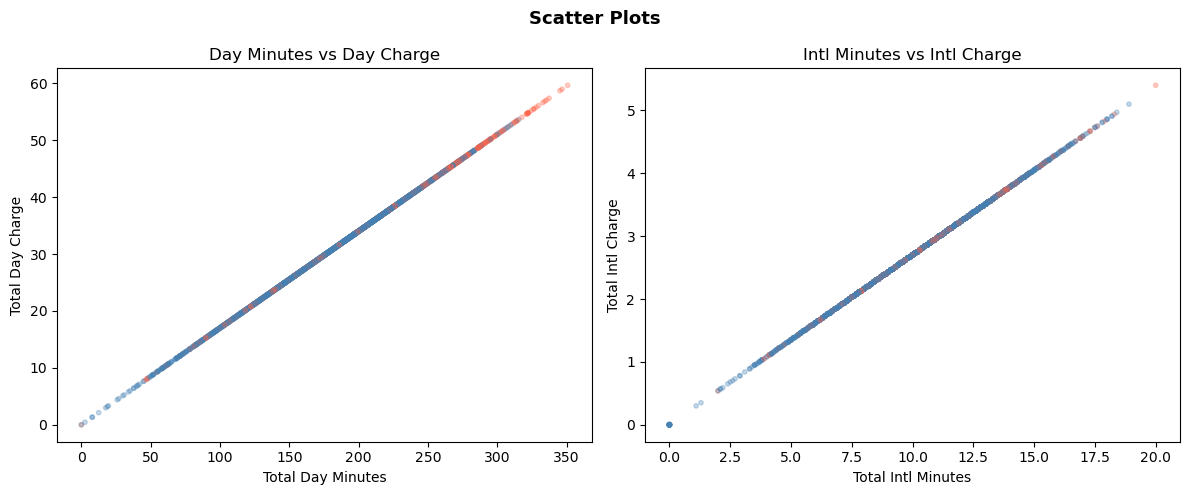

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
fig.suptitle('Scatter Plots', fontsize=13, fontweight='bold')

colors = df['Churn'].map({0: 'steelblue', 1: 'tomato'}) # Map churn values to colors for scatter plots
axes[0].scatter(df['Total day minutes'], df['Total day charge'], # Scatter plot for day minutes vs day charge
                c=colors, alpha=0.3, s=10)
axes[0].set_xlabel('Total Day Minutes')
axes[0].set_ylabel('Total Day Charge')
axes[0].set_title('Day Minutes vs Day Charge')

axes[1].scatter(df['Total intl minutes'], df['Total intl charge'], # Scatter plot for intl minutes vs intl charge
                c=colors, alpha=0.3, s=10) 
axes[1].set_xlabel('Total Intl Minutes')
axes[1].set_ylabel('Total Intl Charge')
axes[1].set_title('Intl Minutes vs Intl Charge')

plt.tight_layout()

### Box Plots

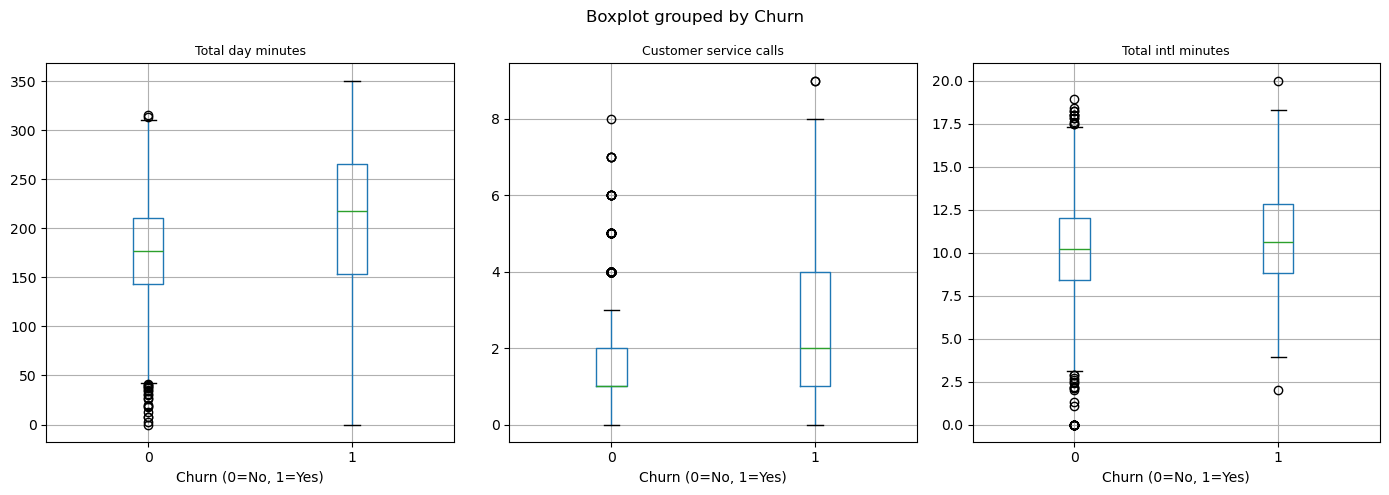

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Box Plots by Churn', fontsize=13, fontweight='bold') # Box plots for selected features by churn status

for ax, col in zip(axes, ['Total day minutes', 'Customer service calls', 'Total intl minutes']): # Loop through selected columns and plot box plots
    df.boxplot(column=col, by='Churn', ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('Churn (0=No, 1=Yes)')

plt.tight_layout()

### Correlation Matrix


Correlation Matrix
                        Total day minutes  Total day charge  Total eve charge  Total night charge  Total intl charge  Customer service calls  Churn
Total day minutes                   1.000             1.000             0.007               0.004             -0.010                  -0.013  0.205
Total day charge                    1.000             1.000             0.007               0.004             -0.010                  -0.013  0.205
Total eve charge                    0.007             0.007             1.000              -0.013             -0.011                  -0.013  0.093
Total night charge                  0.004             0.004            -0.013               1.000             -0.015                  -0.009  0.035
Total intl charge                  -0.010            -0.010            -0.011              -0.015              1.000                  -0.010  0.068
Customer service calls             -0.013            -0.013            -0.013              -

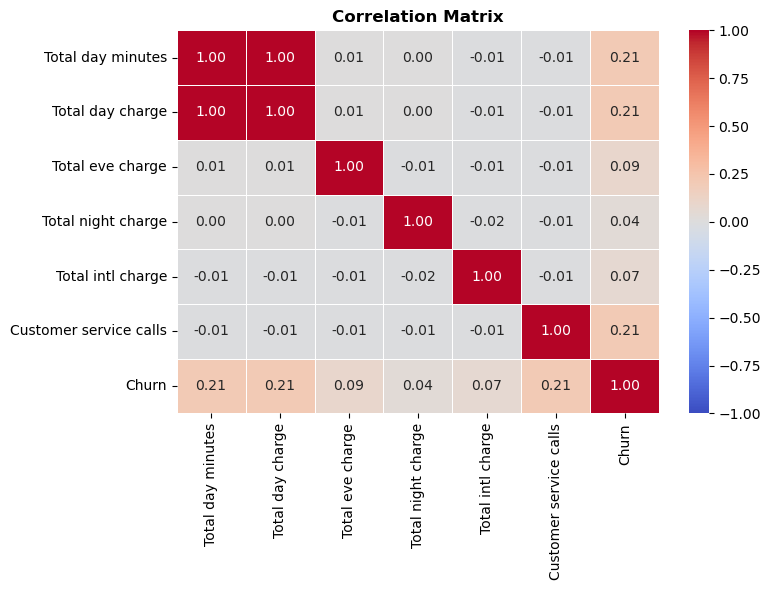

In [ ]:
sel = ['Total day minutes', 'Total day charge', 'Total eve charge',
       'Total night charge', 'Total intl charge', 'Customer service calls', 'Churn'] # Selected columns for correlation analysis
corr = df[sel].corr() # Calculate correlation matrix for selected columns

print("\nCorrelation Matrix") 
print(corr.round(3).to_string())

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1) # Heatmap of correlation matrix with annotations
plt.title('Correlation Matrix', fontweight='bold')
plt.tight_layout()

## EDA Insights Report

In [43]:
print(f"Dataset shape: {df.shape}")
print(f"Overall churn rate: {df['Churn'].mean()*100:.2f}%")

Dataset shape: (3333, 20)
Overall churn rate: 14.49%


In [44]:
print(f"Churn rate with 4+ service calls: {df[df['Customer service calls']>=4]['Churn'].mean()*100:.2f}%")


Churn rate with 4+ service calls: 51.69%


In [45]:
print(f"Intl plan churn - Yes: {df[df['International plan']=='Yes']['Churn'].mean()*100:.1f}%, No: {df[df['International plan']=='No']['Churn'].mean()*100:.2f}%")

Intl plan churn - Yes: 42.4%, No: 11.50%


In [46]:
print(f"Day minutes vs charge correlation: {df[['Total day minutes','Total day charge']].corr().iloc[0,1]:.4f}")

Day minutes vs charge correlation: 1.0000
